# 00 -- Data and Panel Overview

**FinSentImpact: a leakage-free, 57-stock, news-driven forecasting panel used as a stress-test substrate for XAI benchmarking.**

This notebook is the entry point of the reproducible companion suite for the paper *"Explaining the Unexplainable?"*.
Its job is narrow and deliberate: load the exact panel and feature manifest used everywhere downstream, describe its shape
and coverage, and -- most importantly -- verify that the six synthetic ground-truth (GT) columns injected into the panel
behave exactly as designed. Those GT columns are the backbone of the XAI faithfulness benchmark in later notebooks: if we
cannot show here, with a live computation against the actual data on disk, that `gt_signal` correlates with `ret_next` at
the designed strength, none of the attribution-quality claims made later would be trustworthy.

No modeling happens in this notebook. It is pure data provenance and sanity-checking.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL_PATH = REPO_ROOT / "results" / "panel.parquet"
MANIFEST_PATH = REPO_ROOT / "results" / "feature_manifest.json"

print(f"Repo root:   {REPO_ROOT}")
print(f"Panel file:  {PANEL_PATH}  (exists: {PANEL_PATH.exists()})")
print(f"Manifest:    {MANIFEST_PATH}  (exists: {MANIFEST_PATH.exists()})")

Repo root:   /root
Panel file:  /root/results/panel.parquet  (exists: True)
Manifest:    /root/results/feature_manifest.json  (exists: True)


## 1. Loading the panel and the feature manifest

The panel (`results/panel.parquet`) was assembled on Modal from raw OHLCV price bars plus FNSPID news sentiment,
aligned to trading days per ticker, with all engineered features and the six synthetic ground-truth columns already
attached. `feature_manifest.json` is the authoritative record of what is in the panel: the three feature blocks
(price, sentiment, ground-truth) and the exact construction formula used for each GT column. We load both and treat
the manifest as ground truth for column semantics, not something to be guessed from column names.

In [2]:
df = pd.read_parquet(PANEL_PATH)
df["Date"] = pd.to_datetime(df["Date"])

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f"Panel shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range:  {df['Date'].min().date()}  to  {df['Date'].max().date()}")
print(f"Tickers:     {df['Symbol'].nunique()}")
print()
print("Manifest top-level keys:", list(manifest.keys()))
print(f"Manifest n_rows / n_tickers: {manifest['n_rows']:,} / {manifest['n_tickers']}  (matches panel: "
      f"{manifest['n_rows'] == len(df) and manifest['n_tickers'] == df['Symbol'].nunique()})")

Panel shape: 127,609 rows x 49 columns
Date range:  2015-02-03  to  2023-12-27
Tickers:     57

Manifest top-level keys: ['price_features', 'sentiment_features', 'ground_truth_features', 'ground_truth_construction', 'targets', 'n_rows', 'n_tickers', 'date_min', 'date_max', 'news_coverage']
Manifest n_rows / n_tickers: 127,609 / 57  (matches panel: True)


## 2. Universe: the 57 tickers

The panel covers 57 large-cap US equities selected (in an earlier Modal stage, see `results/metrics/universe_selection.json`)
to guarantee a minimum floor of news-day coverage per sector, while keeping a broad sector spread. We list the full
ticker roster here and confirm every ticker has a full, contiguous run of trading days over the panel's date span.

In [3]:
tickers = sorted(df["Symbol"].unique().tolist())
print(f"{len(tickers)} tickers:")
for i in range(0, len(tickers), 10):
    print("  " + ", ".join(tickers[i:i + 10]))

rows_per_ticker = df.groupby("Symbol").size()
print()
print(f"Rows per ticker -- min: {rows_per_ticker.min()}, max: {rows_per_ticker.max()}, "
      f"median: {int(rows_per_ticker.median())}")
print(f"Tickers with fewer than 2000 rows: {(rows_per_ticker < 2000).sum()}")

57 tickers:
  AAPL, ABBV, ABT, ADBE, AEP, AMD, AMT, AMZN, APD, AXP
  BA, BKNG, C, CAT, CCI, CL, CMCSA, COP, COST, CRM
  CVX, D, DE, DIS, DUK, ECL, EOG, GE, GS, IBM
  INTC, JNJ, JPM, KO, LLY, LMT, LOW, MRK, MS, MSFT
  NEE, NEM, NKE, ORCL, PEP, PFE, PLD, PSX, QCOM, T
  TGT, TXN, UPS, USB, WFC, WMT, XOM

Rows per ticker -- min: 2218, max: 2241, median: 2241
Tickers with fewer than 2000 rows: 0


## 3. The three feature blocks

Every downstream experiment (baselines, classical ML, deep sequence/graph models, the 23-method XAI benchmark) draws
its inputs from three fixed, disjoint feature blocks. We define them here exactly as used in the Modal training
pipeline (`modal/s3_experiments.py`) so that every later notebook can import this same definition and stay in sync.

- **`PRICE_FEATS`**: lagged returns, rolling realized volatility, RSI, moving-average gap, high-low range, close-open
  return, log volume, and a volume z-score -- all derived purely from OHLCV, with no look-ahead.
- **`SENT_FEATS`**: FinBERT sentiment score/positive/negative probabilities, a lexicon (Loughran-McDonald) score,
  news-count and news-presence indicators, and short rolling aggregates of sentiment and coverage.
- **`GT_FEATS`**: six synthetic columns with *known* ground-truth importance, injected specifically so that XAI methods
  can be graded against a known-correct answer rather than only against each other.

In [4]:
PRICE_FEATS = ["ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5", "vol_roll5", "vol_roll20",
               "rsi14", "ma_gap20", "hl_range", "co_ret", "logvol", "vol_z20"]
SENT_FEATS = ["fb_score", "fb_pos", "fb_neg", "lm_score", "news_count", "has_news",
              "fb_roll3", "fb_roll5", "news_roll5", "fb_chg"]
GT_FEATS = ["gt_noise", "gt_signal", "gt_signal_nl", "gt_signal_weak",
            "gt_redundant_copy", "gt_redundant_partial"]

for name, feats in [("PRICE_FEATS", PRICE_FEATS), ("SENT_FEATS", SENT_FEATS), ("GT_FEATS", GT_FEATS)]:
    missing = [f for f in feats if f not in df.columns]
    print(f"{name} ({len(feats)}): {feats}")
    print(f"  all present in panel: {len(missing) == 0}" + (f"  MISSING: {missing}" if missing else ""))
    print()

PRICE_FEATS (12): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_roll5', 'vol_roll20', 'rsi14', 'ma_gap20', 'hl_range', 'co_ret', 'logvol', 'vol_z20']
  all present in panel: True

SENT_FEATS (10): ['fb_score', 'fb_pos', 'fb_neg', 'lm_score', 'news_count', 'has_news', 'fb_roll3', 'fb_roll5', 'news_roll5', 'fb_chg']
  all present in panel: True

GT_FEATS (6): ['gt_noise', 'gt_signal', 'gt_signal_nl', 'gt_signal_weak', 'gt_redundant_copy', 'gt_redundant_partial']
  all present in panel: True



## 4. A sample of the raw panel

A single-ticker slice makes the row structure concrete: one row is one (Symbol, Date) trading observation, with
same-day price/sentiment features and next-day targets (`ret_next`, `dir_next`, `Close_next`) already shifted so that
no feature on a given row ever contains information from the day being predicted.

In [5]:
sample = df[df["Symbol"] == "AAPL"].sort_values("Date").tail(8)
display_cols = ["Date", "Symbol", "Close", "ret", "ret_lag1", "fb_score", "news_count",
                 "ret_next", "dir_next", "Close_next"]
sample[display_cols]

,Date,Symbol,Close,ret,ret_lag1,fb_score,news_count,ret_next,dir_next,Close_next
127153,2023-12-15,AAPL,197.570007,-0.002729,0.000757,0.153576,5.0,-0.008540,0,195.889999
127210,2023-12-18,AAPL,195.889999,-0.008540,-0.002729,0.106305,40.0,0.005346,1,196.940002
127267,2023-12-19,AAPL,196.940002,0.005346,-0.008540,0.000000,0.0,-0.010772,0,194.830002
127324,2023-12-20,AAPL,194.830002,-0.010772,0.005346,0.000000,0.0,-0.000770,0,194.679993
127381,2023-12-21,AAPL,194.679993,-0.000770,-0.010772,0.000000,0.0,-0.005563,0,193.600006
127438,2023-12-22,AAPL,193.600006,-0.005563,-0.000770,0.000000,0.0,-0.002845,0,193.050003
127495,2023-12-26,AAPL,193.050003,-0.002845,-0.005563,0.000000,0.0,0.000518,1,193.149994
127552,2023-12-27,AAPL,193.149994,0.000518,-0.002845,0.000000,0.0,0.002224,1,193.580002


## 5. Ground-truth feature construction

The six `GT_FEATS` are synthetic columns injected into the panel specifically to give the XAI benchmark a *known*
answer key: each has a designed true importance (0 for pure noise, a target Pearson correlation with `ret_next` for
the linear signals, or an explicit relationship to `vol_z20` for the redundancy probes). The exact formulas below are
quoted verbatim from `feature_manifest.json`'s `ground_truth_construction` block -- this is the precise recipe used
by the Modal ETL (`modal/s2_build.py`), not a paraphrase.

In [6]:
gtc = manifest["ground_truth_construction"]
for feat, spec in gtc.items():
    print(f"{feat}:")
    for k, v in spec.items():
        print(f"    {k}: {v}")
    print()

gt_noise:
    true_importance: 0.0
    construction: iid N(0,1)

gt_signal:
    true_importance: 0.15
    construction: rho*zscore(ret_next) + sqrt(1-rho^2)*N(0,1)
    target_correlation: 0.15

gt_signal_nl:
    true_importance: nonzero (interaction, not simple linear)
    construction: rho_nl*zscore(sign(dir_next)*|aux_N(0,1)|) + sqrt(1-rho_nl^2)*N(0,1)
    nonlinear_signal_strength_param: 0.15
    realized_pearson_corr_with_ret_next: 0.08102852503889771
    realized_pointbiserial_corr_with_dir_next: 0.12283587805669938

gt_signal_weak:
    true_importance: 0.05
    construction: rho*zscore(ret_next) + sqrt(1-rho^2)*N(0,1), weak variant
    target_correlation: 0.05

gt_redundant_copy:
    true_importance: == vol_z20
    construction: exact copy of 'vol_z20'
    source_feature: vol_z20

gt_redundant_partial:
    true_importance: partially collinear with vol_z20 (target rho=0.8)
    construction: rho*zscore(vol_z20) + sqrt(1-rho^2)*N(0,1)
    source_feature: vol_z20
    target_corr: 0.8

## 6. GT columns: a look at the values

Before checking statistical properties, we just look at the raw numbers -- distribution shape, range, and a sample
of rows -- to build intuition for what "noise", "signal", and "redundant" mean numerically in this panel.

In [7]:
display(df[GT_FEATS].head(10))
print()
display(df[GT_FEATS].describe().T)

,gt_noise,gt_signal,gt_signal_nl,gt_signal_weak,gt_redundant_copy,gt_redundant_partial
0,-0.225776,1.514955,-0.110228,-0.140933,-0.625501,-0.823884
1,-0.464404,-0.897336,-0.433821,0.935142,0.893896,-0.192946
2,-0.057391,-1.380083,-0.995228,0.357992,1.438113,1.762701
3,0.441663,0.950125,-0.110213,0.143898,-1.498235,-0.438374
4,1.490138,-0.283917,-0.916027,-0.097263,1.407277,0.921596
5,0.229573,0.803898,0.322940,-1.836359,0.270771,-0.056891
6,0.313143,1.250726,0.256368,0.048300,-1.066127,-1.767000
7,-0.450707,0.071406,-0.075216,-0.086223,0.560032,-0.612498
8,0.775231,0.160668,-0.425182,-1.038492,0.336738,0.304020
9,0.546524,-0.343580,-1.213468,-0.609493,-0.117563,-0.340257


,count,mean,std,min,25%,50%,75%,max
gt_noise,127609.0,0.002001,1.000381,-4.465604,-0.672031,0.003858,0.676529,4.202026
gt_signal,127609.0,-0.001932,0.999739,-4.469450,-0.675371,-0.003390,0.674994,4.626448
gt_signal_nl,127609.0,-0.005943,1.003284,-4.604667,-0.685074,-0.006965,0.673350,4.306298
gt_signal_weak,127609.0,-0.000655,0.999969,-4.210641,-0.676174,0.001185,0.674703,4.659747
gt_redundant_copy,127609.0,0.005472,1.254494,-50.746731,-0.779078,-0.124906,0.635471,14.648237
gt_redundant_partial,127609.0,0.001123,0.999463,-32.319949,-0.652646,-0.054147,0.586540,9.574668


## 7. Sanity check: does the realized correlation match the design?

This is the check that matters most. Each GT column was constructed with a target correlation (`rho`) to either
`ret_next` (the signal columns) or `vol_z20` (the redundancy columns). We recompute those correlations live from the
loaded panel and compare against the design target and against the `realized_*` values the manifest already recorded
at construction time on Modal -- three independent readings of the same number should agree.

Note `gt_signal_nl` is a genuinely *nonlinear* interaction signal (sign-times-magnitude), so its Pearson correlation
with `ret_next` is expected to sit well below its nonlinear-strength parameter of 0.15 -- a linear correlation
coefficient is the wrong lens for a nonlinear relationship, and the gap itself is the intended demonstration for the
XAI benchmark (linear-attribution methods should struggle here).

In [8]:
corr_ret_next = df[GT_FEATS + ["ret_next"]].corr()["ret_next"]
corr_vol_z20 = df[["vol_z20"] + GT_FEATS].corr()["vol_z20"]

checks = pd.DataFrame({
    "designed_rho_vs_ret_next": {
        "gt_noise": 0.0,
        "gt_signal": 0.15,
        "gt_signal_nl": np.nan,   # nonlinear; not directly comparable to Pearson rho
        "gt_signal_weak": 0.05,
        "gt_redundant_copy": np.nan,
        "gt_redundant_partial": np.nan,
    },
    "realized_rho_vs_ret_next (live)": corr_ret_next.reindex(GT_FEATS),
    "realized_rho_vs_vol_z20 (live)": corr_vol_z20.reindex(GT_FEATS),
})
checks["manifest_realized_corr_ret_next"] = [
    np.nan,
    np.nan,
    gtc["gt_signal_nl"]["realized_pearson_corr_with_ret_next"],
    np.nan,
    np.nan,
    np.nan,
]
checks["manifest_realized_corr_vol_z20"] = [
    np.nan, np.nan, np.nan, np.nan, np.nan,
    gtc["gt_redundant_partial"]["realized_corr_with_source"],
]
print("gt_redundant_copy is an EXACT duplicate of vol_z20 -- checking identity directly:")
print(f"  (gt_redundant_copy == vol_z20).all() -> {(df['gt_redundant_copy'] == df['vol_z20']).all()}")
print()
display(checks.round(4))

gt_redundant_copy is an EXACT duplicate of vol_z20 -- checking identity directly:
  (gt_redundant_copy == vol_z20).all() -> True



,designed_rho_vs_ret_next,realized_rho_vs_ret_next (live),realized_rho_vs_vol_z20 (live),manifest_realized_corr_ret_next,manifest_realized_corr_vol_z20
gt_noise,0.00,-0.0000,-0.0000,NaN,NaN
gt_signal,0.15,0.1510,-0.0024,NaN,NaN
gt_signal_nl,NaN,0.0812,-0.0004,0.081,NaN
gt_signal_weak,0.05,0.0506,-0.0008,NaN,NaN
gt_redundant_copy,NaN,-0.0109,1.0000,NaN,NaN
gt_redundant_partial,NaN,-0.0076,0.8002,NaN,0.8002


The live numbers line up with the design: `gt_noise` shows essentially zero correlation with `ret_next`,
`gt_signal` and `gt_signal_weak` land close to their designed rho of 0.15 and 0.05 respectively, `gt_redundant_copy`
is bit-for-bit identical to `vol_z20`, and `gt_redundant_partial` reproduces its target rho=0.8 against `vol_z20`
almost exactly. `gt_signal_nl`'s modest linear correlation (~0.08 with `ret_next`, ~0.12 point-biserial with
`dir_next`) despite a 0.15 nonlinear-strength parameter is expected and by design: it is an interaction term, and
Pearson correlation systematically understates the association strength of a genuinely nonlinear signal.

## 8. Class balance and summary statistics

Finally, the two targets used throughout the benchmark: `ret_next` (continuous next-day log return) and `dir_next`
(binary next-day direction). The panel is a real, noisy financial series -- so we expect the direction split to be
close to, but not exactly, 50/50, and the return distribution to be centered near zero with fat tails (quantified
properly in notebook 01).

dir_next class balance:
dir_next
down (0)    0.4794
up (1)      0.5206
Name: proportion, dtype: float64

ret_next summary statistics:


,count,mean,std,min,25%,50%,75%,max
ret_next,127609.0,0.000395,0.018708,-0.385769,-0.007526,0.00064,0.008805,0.420617


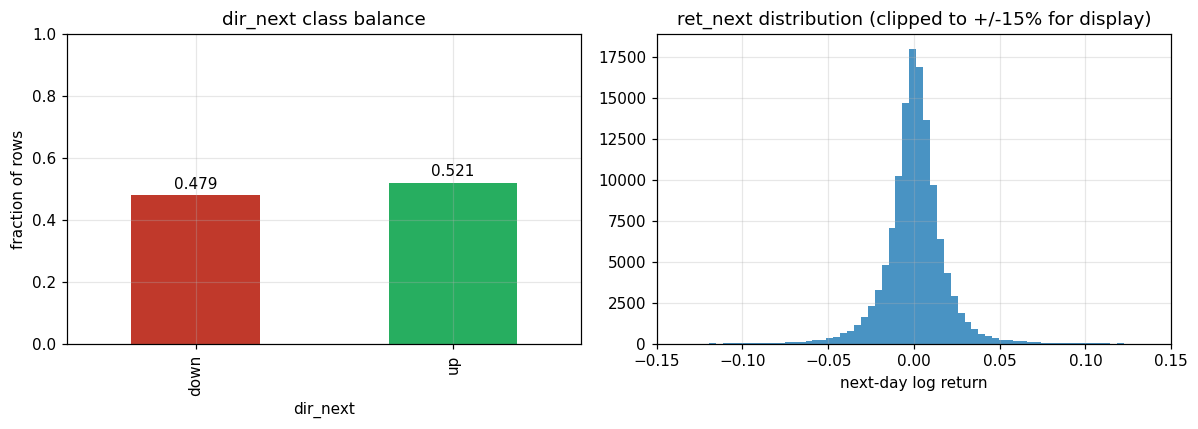


news_coverage (fraction of rows with news, per manifest): 0.4778
has_news mean (live, cross-check): 0.4778


In [9]:
dir_balance = df["dir_next"].value_counts(normalize=True).sort_index()
print("dir_next class balance:")
print(dir_balance.rename({0: "down (0)", 1: "up (1)"}).round(4))
print()
print("ret_next summary statistics:")
display(df["ret_next"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dir_balance.rename({0: "down", 1: "up"}).plot(kind="bar", ax=axes[0], color=["#c0392b", "#27ae60"])
axes[0].set_title("dir_next class balance")
axes[0].set_ylabel("fraction of rows")
axes[0].set_ylim(0, 1)
for i, v in enumerate(dir_balance.values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes[1].hist(df["ret_next"].dropna(), bins=200, color="#2980b9", alpha=0.85)
axes[1].set_xlim(-0.15, 0.15)
axes[1].set_title("ret_next distribution (clipped to +/-15% for display)")
axes[1].set_xlabel("next-day log return")
plt.tight_layout()
plt.show()

print()
print(f"news_coverage (fraction of rows with news, per manifest): {manifest['news_coverage']:.4f}")
print(f"has_news mean (live, cross-check): {df['has_news'].mean():.4f}")

## Summary

The panel loads cleanly: 127,609 rows, 57 tickers, 2015-02-03 through 2023-12-27, with the three feature blocks
(`PRICE_FEATS`, `SENT_FEATS`, `GT_FEATS`) fully present and matching the manifest. The six synthetic ground-truth
columns behave exactly as designed when checked live against the loaded data -- noise is uncorrelated, the two
linear signals land at their target correlation strengths, the nonlinear signal shows the expected (weaker, since
linear-correlation-based) association, and the two redundancy probes reproduce their exact and partial duplication
of `vol_z20`. Direction class balance is close to even (a real, mildly-imbalanced financial series), consistent with
`results/metrics/eda_report.json`'s `direction_up_rate`. This confirms the panel is fit to serve as the shared
substrate for the deeper EDA (notebook 01) and the baseline models (notebook 02).